In [91]:
import numpy as np
import pandas as pd
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.decomposition import PCA

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

import matplotlib.pyplot as plt
import imgkit

#### Declaramos las funcionas a utilizar

In [2]:
def normalise_data(scaler_x, x, scaler_y, y):# Utiliza MinMaxScaler
    X_train = pd.DataFrame(scaler_x.fit_transform(x))
    y_train = pd.DataFrame(scaler_y.fit_transform(y.values.reshape(-1, 1)))
    return X_train, y_train

In [3]:
def create_sequences(X, y, seq_length):
    xs = []
    ys = []

    for i in range(len(X)-seq_length):
        xs.append(X[i:(i+seq_length)])
        ys.append(y[i+seq_length])

    return np.array(xs), np.array(ys)

In [4]:
def df_to_image(df, filename):
    """
    Convert a pandas DataFrame into a styled PNG image, maintaining the order of the DataFrame as it is passed.

    Args:
      df (pandas.DataFrame): The DataFrame to convert.
      filename (str): The base name of the files to create. The HTML file will be named
          '{filename}.html' and the image file will be named '{filename}.png'.
    """
    
    sampled_df = df  # Si hay 10 o menos filas, mostrar todo el DataFrame

    # Redondear y estilizar el DataFrame
    styled = sampled_df.style.format(precision=2).set_table_styles(
        [dict(selector="tr:nth-of-type(odd) td", props=[("background", "#eee")]),
         dict(selector="tr:nth-of-type(even) td", props=[("background", "white")])])

    # Guardar como HTML y luego convertir a PNG
    html_file = f'{filename}.html'
    styled.to_html(html_file)
    imgkit.from_file(html_file, f'{filename}.png')
    os.remove(html_file)

#### Leemos los datos

In [5]:
sensor_ids = [
    "200034001951343334363036",
    "270043001951343334363036",
    "380033001951343334363036",
    "46004e000251353337353037",
    "46005a000351353337353037",
    "4e0022000251353337353037",
    "4e0031000251353337353037"]

In [6]:
# Primero
id_train = "270043001951343334363036"
id_test = "46004e000251353337353037"

In [7]:
# Segundo
#id_train = "4e0031000251353337353037"
#id_test = "46004e000251353337353037"

In [8]:
# ESTE Cuarto
#id_train = "380033001951343334363036"
#id_test = "46005a000351353337353037" 

In [9]:
# Quinto
#id_train = "4e0031000251353337353037"
#id_test = "46005a000351353337353037"

In [10]:
seq_length = 72
forecast_steps = seq_length 
future_steps = 1
intervalo = "15min"

In [11]:
quitar = ["soil_humidity"]
re_sample = "1h"
cut_train = 0
cut_test = 0

In [12]:
completos_dir = "../src/datos"
data_origen = "../src/data_download"

In [13]:
sensors_data_clean = {id: pd.read_csv(f"../src/datos/{id}_limpios_{intervalo}.csv", index_col=0, parse_dates=True) for id in sensor_ids}

In [14]:
train_dataset = sensors_data_clean[id_train][cut_train:]
test_dataset = sensors_data_clean[id_test][cut_test:]

In [15]:
# Resample the DataFrame to 1-hour intervals, taking the mean of each interval
train_dataset = train_dataset.resample(re_sample).mean().ffill()
test_dataset = test_dataset.resample(re_sample).mean().ffill()

In [16]:
# Reset the index to make 'date' a column again
train_dataset.reset_index(inplace=True)
test_dataset.reset_index(inplace=True)

In [17]:
# Extract the hour from the 'date' column
train_dataset["hora"] = train_dataset["fecha"].dt.hour
test_dataset["hora"]  = test_dataset["fecha"].dt.hour

In [18]:
train_dataset = train_dataset.set_index("fecha")
test_dataset = test_dataset.set_index("fecha")

In [19]:
# Eliminamos variables no deseadas
train_dataset = train_dataset.drop(columns=quitar)
test_dataset2 = test_dataset.drop(columns=quitar).copy()
test_dataset = test_dataset.drop(columns=["soil_humidity"])

In [20]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,,
2018-05-06 00:00:00,15.056667,991.876667,72.690000,57.913333,0.0000,0.0,848.0,0
2018-05-06 01:00:00,12.505000,991.825000,69.382500,61.760000,0.6025,0.0,848.0,1
2018-05-06 02:00:00,11.056667,991.530000,66.723333,63.773333,0.0000,0.0,848.0,2
2018-05-06 03:00:00,10.866667,991.260000,63.733333,66.053333,0.0000,0.0,848.0,3
2018-05-06 04:00:00,12.347500,991.062500,61.465000,66.192500,0.6025,0.0,848.0,4


In [21]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,,
2018-05-14 00:00:00,10.670000,987.840,0.020000,42.950000,2.410000,0.0,864.0,0
2018-05-14 01:00:00,10.010000,987.845,2.335000,41.695000,0.000000,0.0,864.0,1
2018-05-14 02:00:00,9.293333,987.490,4.346667,45.693333,0.803333,0.0,864.0,2
2018-05-14 03:00:00,11.330000,986.755,13.330000,45.570000,2.410000,0.0,864.0,3
2018-05-14 04:00:00,13.295000,986.590,8.860000,43.707500,3.015000,0.0,864.0,4


In [22]:
# Seleccion las características y la variable objetivo del conjunto de entrenamiento
X_train = train_dataset[["temperature", "pressure", "air_humidity", "wind_speed", "irradiancia","minutos_dia", "hora"]]
y_train = train_dataset["battery"]

In [23]:
# Selección las características y la variable objetivo del conjunto de entrenamiento
X_test = test_dataset[["temperature", "pressure", "air_humidity", "wind_speed", "irradiancia","minutos_dia", "hora"]]
y_test = test_dataset["battery"]

In [24]:
# Dividir los datos en entrenamiento y prueba
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Instanciamos los escaladores
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

In [26]:
# Normalizamos los conjuntos de datos de entrenamiento y test
X_train_norm, y_train_norm = normalise_data(scaler_x, X_train, scaler_y, y_train)
X_test_norm, y_test_norm = normalise_data(scaler_x, X_test, scaler_y, y_test)

In [27]:
X_train_norm.columns = ["temperature", "pressure", "air_humidity", "wind_speed", "irradiancia","minutos_dia", "hora"] 
X_train_norm.index = train_dataset.index
X_train_norm

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-05-06 00:00:00,0.200275,0.574522,0.631946,0.000000,0.0,0.658683,0.000000
2018-05-06 01:00:00,0.135587,0.571512,0.696105,0.062435,0.0,0.658683,0.043478
2018-05-06 02:00:00,0.098870,0.554326,0.729686,0.000000,0.0,0.658683,0.086957
2018-05-06 03:00:00,0.094053,0.538596,0.767715,0.000000,0.0,0.658683,0.130435
2018-05-06 04:00:00,0.131594,0.527090,0.770036,0.062435,0.0,0.658683,0.173913
...,...,...,...,...,...,...,...
2018-09-19 20:00:00,0.450893,0.713225,0.831457,0.062435,0.0,0.017964,0.869565
2018-09-19 21:00:00,0.403106,0.724294,0.917188,0.000000,0.0,0.017964,0.913043
2018-09-19 22:00:00,0.384536,0.747306,0.964223,0.000000,0.0,0.017964,0.956522


In [28]:
X_test_norm.columns = ["temperature", "pressure", "air_humidity", "wind_speed", "irradiancia","minutos_dia", "hora"] 
X_test_norm.index = test_dataset.index
X_test_norm

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-05-14 00:00:00,0.054664,0.892807,0.381918,0.257823,0.0,0.0,0.000000
2018-05-14 01:00:00,0.033688,0.893206,0.360935,0.000000,0.0,0.0,0.043478
2018-05-14 02:00:00,0.010912,0.864913,0.427785,0.085941,0.0,0.0,0.086957
2018-05-14 03:00:00,0.075640,0.806336,0.425723,0.257823,0.0,0.0,0.130435
2018-05-14 04:00:00,0.138090,0.793186,0.394583,0.322546,0.0,0.0,0.173913
...,...,...,...,...,...,...,...
2018-06-14 20:00:00,0.592245,0.527197,0.304297,0.000000,0.0,1.0,0.869565
2018-06-14 21:00:00,0.469728,0.592150,0.373182,0.000000,0.0,1.0,0.913043
2018-06-14 22:00:00,0.380025,0.628014,0.417071,0.000000,0.0,1.0,0.956522


### REGRESION LINEAL

#### Autoregresion AutoReg y SARIMAX

In [29]:
import scipy.stats as stats

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [31]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

In [32]:
from mlforecast import MLForecast
from statsforecast import StatsForecast
from mlforecast.target_transforms import Differences
from mlforecast.utils import PredictionIntervals

/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


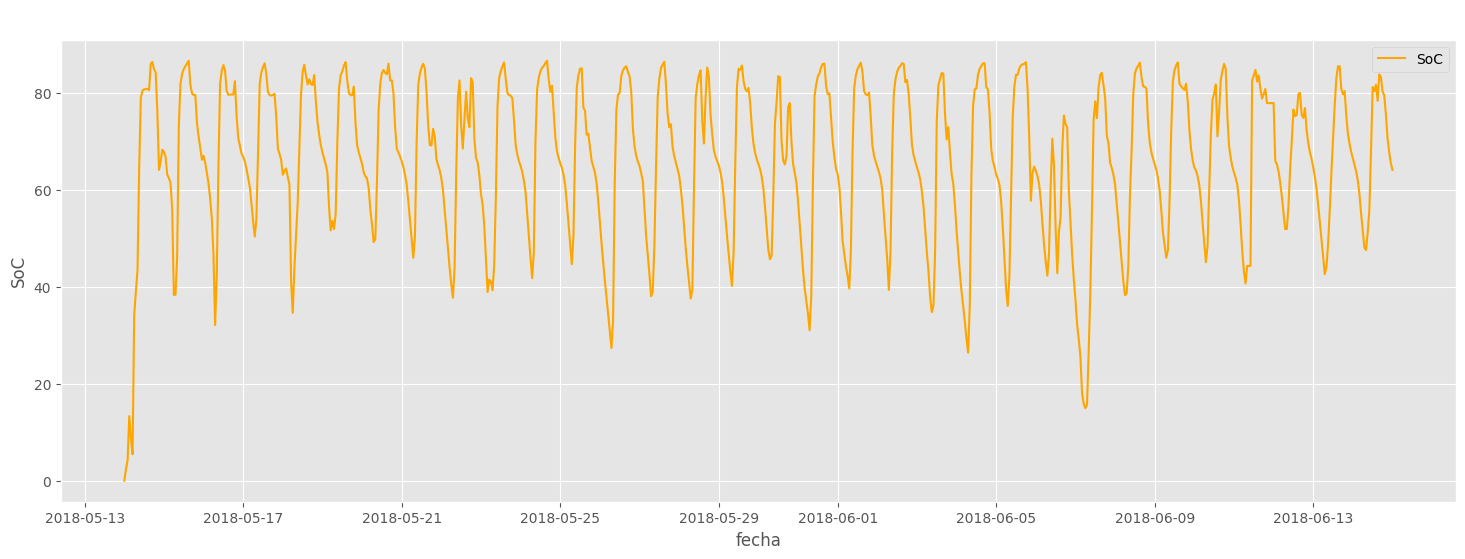

In [33]:
plt.style.use("ggplot")
plt.figure(figsize=(18,6))
plt.plot(test_dataset["battery"], color="orange", label="SoC")
plt.title(" ", fontsize=20)
plt.xlabel("fecha")
plt.ylabel("SoC")
plt.legend()
plt.show()

In [34]:
# Seleccionar la variable 'battery' para el modelo autoregresivo
#battery_data = train_dataset['battery']
#battery_data2 = test_dataset["battery"]

In [35]:
train_dataset2 = train_dataset[0:2500]
train_size = int(len(train_dataset) * 0.7)
train_data = train_dataset['battery'][:train_size]
test_data = train_dataset['battery'][train_size:]

In [36]:
train_data = train_data.asfreq("h")

In [37]:
train_data.head()

fecha
2018-05-06 00:00:00    72.690000
2018-05-06 01:00:00    69.382500
2018-05-06 02:00:00    66.723333
2018-05-06 03:00:00    63.733333
2018-05-06 04:00:00    61.465000
Freq: h, Name: battery, dtype: float64

In [38]:
# Aplicar el modelo AutoReg
train_data = train_data.asfreq("h")
lag = 72  # Ajusta según tu necesidad, en este caso estamos usando 3 para ilustrar
model = AutoReg(train_data, lags=lag)
model_fit = model.fit()

In [39]:
# Realizar predicciones para los próximos 3 pasos (esto puede ajustarse)
forecast_steps = len(test_data)
forecast = model_fit.predict(start=len(train_data), end=len(train_data) + 72)

In [40]:
# Evaluar las predicciones: Calcular MAE y RMSE
mae = mean_absolute_error(test_data[0:73], forecast)
rmse = np.sqrt(mean_squared_error(test_data[0:73], forecast))

In [41]:
# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse}")

MAE (Error Absoluto Medio): 3.4202201423327394
RMSE (Raíz del Error Cuadrático Medio): 4.881747995199543


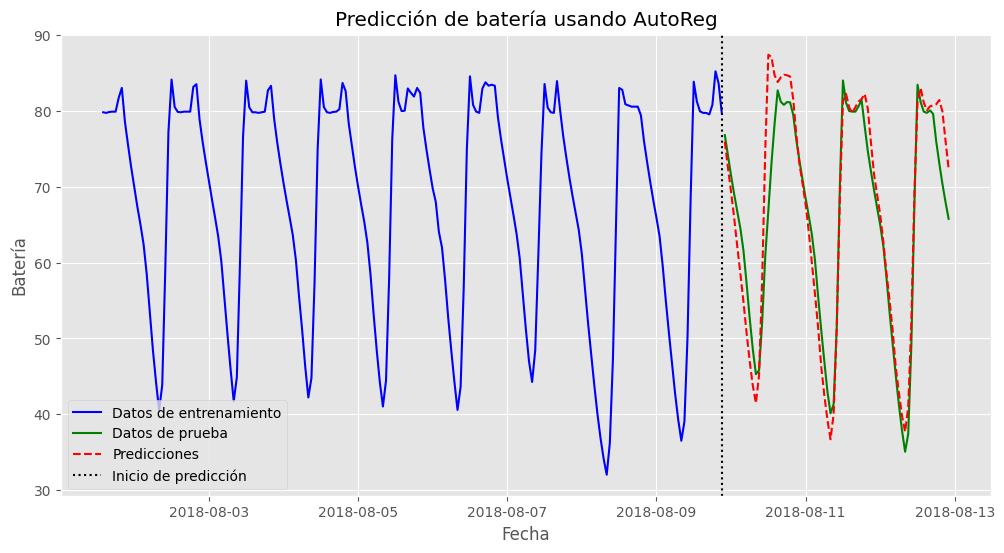

In [42]:
# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-200:], train_data[-200:], label="Datos de entrenamiento", color='blue')
plt.plot(test_data.index[0:73], test_data[0:73], label="Datos de prueba", color='green')
plt.plot(test_data.index[0:73], forecast, label="Predicciones", color='red', linestyle='--')
plt.axvline(train_data.index[-1], color='black', linestyle=':', label="Inicio de predicción")
plt.title("Predicción de batería usando AutoReg")
plt.xlabel("Fecha")
plt.ylabel("Batería")
plt.legend()
plt.grid(True)
plt.savefig("Autoreg_train.png", dpi=300, bbox_inches='tight')
plt.show()

### Datos de TEST no conocidos

In [43]:
test_dataset2 = test_dataset["battery"]
train_size = int(len(test_dataset2) * 0.7)
train_data = test_dataset2[:train_size]
test_data = test_dataset2[train_size:]

In [44]:
# Realizar predicciones
forecast_steps = len(test_data)
forecast = model_fit.predict(start=len(train_data), end=len(train_data) + 72)

In [45]:
# Evaluar las predicciones: Calcular MAE y RMSE
mae = mean_absolute_error(test_data[0:73], forecast)
rmse = np.sqrt(mean_squared_error(test_data[0:73], forecast))

In [46]:
# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse}")

MAE (Error Absoluto Medio): 11.47448541659207
RMSE (Raíz del Error Cuadrático Medio): 15.04824376832916


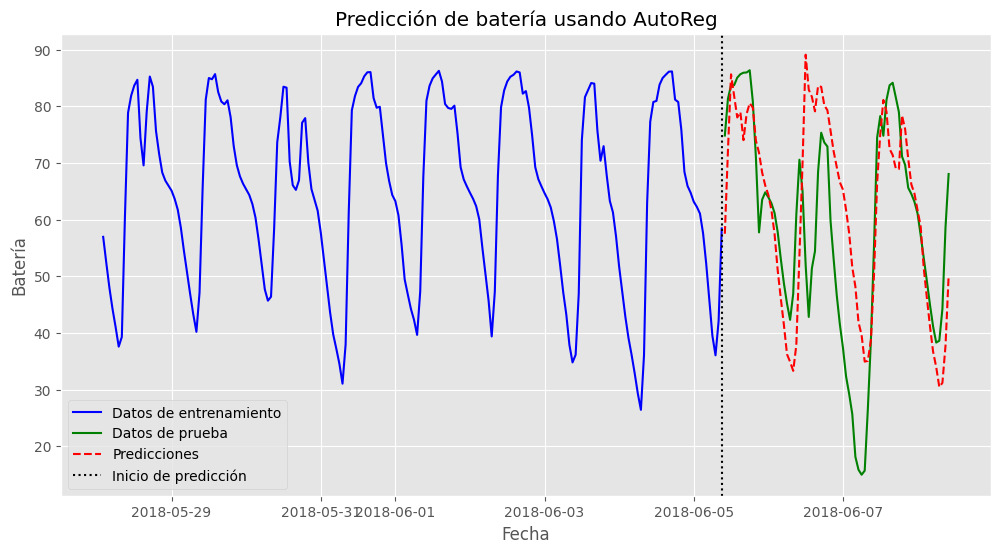

In [47]:
# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-200:], train_data[-200:], label="Datos de entrenamiento", color='blue')
plt.plot(test_data.index[0:73], test_data[0:73], label="Datos de prueba", color='green')
plt.plot(test_data.index[0:73], forecast, label="Predicciones", color='red', linestyle='--')
plt.axvline(train_data.index[-1], color='black', linestyle=':', label="Inicio de predicción")
plt.title("Predicción de batería usando AutoReg")
plt.xlabel("Fecha")
plt.ylabel("Batería")
plt.legend()
plt.grid(True)
plt.savefig("Autoreg_test.png", dpi=300, bbox_inches='tight')
plt.show()

#### SARIMAX

In [48]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,,
2018-05-06 00:00:00,15.056667,991.876667,72.690000,57.913333,0.0000,0.0,848.0,0
2018-05-06 01:00:00,12.505000,991.825000,69.382500,61.760000,0.6025,0.0,848.0,1
2018-05-06 02:00:00,11.056667,991.530000,66.723333,63.773333,0.0000,0.0,848.0,2
2018-05-06 03:00:00,10.866667,991.260000,63.733333,66.053333,0.0000,0.0,848.0,3
2018-05-06 04:00:00,12.347500,991.062500,61.465000,66.192500,0.6025,0.0,848.0,4


In [50]:
X_train_norm.head()

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-05-06 00:00:00,0.200275,0.574522,0.631946,0.000000,0.0,0.658683,0.000000
2018-05-06 01:00:00,0.135587,0.571512,0.696105,0.062435,0.0,0.658683,0.043478
2018-05-06 02:00:00,0.098870,0.554326,0.729686,0.000000,0.0,0.658683,0.086957
2018-05-06 03:00:00,0.094053,0.538596,0.767715,0.000000,0.0,0.658683,0.130435
2018-05-06 04:00:00,0.131594,0.527090,0.770036,0.062435,0.0,0.658683,0.173913


In [51]:
X_test_norm.head()

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-05-14 00:00:00,0.054664,0.892807,0.381918,0.257823,0.0,0.0,0.000000
2018-05-14 01:00:00,0.033688,0.893206,0.360935,0.000000,0.0,0.0,0.043478
2018-05-14 02:00:00,0.010912,0.864913,0.427785,0.085941,0.0,0.0,0.086957
2018-05-14 03:00:00,0.075640,0.806336,0.425723,0.257823,0.0,0.0,0.130435
2018-05-14 04:00:00,0.138090,0.793186,0.394583,0.322546,0.0,0.0,0.173913


In [105]:
# Dividir los datos en entrenamiento y prueba (70% entrenamiento, 30% prueba)
#train_size = int(len(train_dataset) * 0.7)
#train_data = train_dataset['battery'][:train_size]
#test_data = train_dataset['battery'][train_size:]

In [106]:
# Dividir los datos en entrenamiento y prueba (70% entrenamiento, 30% prueba)
train_size = int(len(train_dataset) * 0.7)
train_data = train_dataset['battery'][:train_size]
test_data = train_dataset['battery'][train_size:]

In [107]:
# Establecer las variables exógenas
#exog_train = test_dataset[['temperature', 'pressure', 'air_humidity', 'wind_speed', 'irradiancia', "minutos_dia", "hora"]][:train_size]
#exog_test = train_dataset[['temperature', 'pressure', 'air_humidity', 'wind_speed', 'irradiancia', "minutos_dia", "hora"]][train_size:]
# Establecer las variables exógenas
exog_train = X_train_norm[['temperature', 'pressure', 'air_humidity', 'wind_speed', 'irradiancia', "minutos_dia", "hora"]][:train_size]
exog_test = X_train_norm[['temperature', 'pressure', 'air_humidity', 'wind_speed', 'irradiancia', "minutos_dia", "hora"]][train_size:]

In [108]:
exog_train.head()

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-05-06 00:00:00,0.200275,0.574522,0.631946,0.000000,0.0,0.658683,0.000000
2018-05-06 01:00:00,0.135587,0.571512,0.696105,0.062435,0.0,0.658683,0.043478
2018-05-06 02:00:00,0.098870,0.554326,0.729686,0.000000,0.0,0.658683,0.086957
2018-05-06 03:00:00,0.094053,0.538596,0.767715,0.000000,0.0,0.658683,0.130435
2018-05-06 04:00:00,0.131594,0.527090,0.770036,0.062435,0.0,0.658683,0.173913


In [109]:
exog_test.head()

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-08-09 22:00:00,0.427189,0.604282,0.674631,0.062435,0.0,0.622754,0.956522
2018-08-09 23:00:00,0.398162,0.654821,0.725753,0.000000,0.0,0.622754,1.000000
2018-08-10 00:00:00,0.421802,0.658753,0.703486,0.062435,0.0,0.610778,0.000000
2018-08-10 01:00:00,0.438661,0.693999,0.659244,0.000000,0.0,0.610778,0.043478
2018-08-10 02:00:00,0.436886,0.745995,0.627971,0.562435,0.0,0.610778,0.086957


In [110]:
exog_train = exog_train.asfreq("h")

In [111]:
# Definir y entrenar el modelo SARIMAX
# p, d, q son los parámetros del modelo ARIMA
# P, D, Q, S son los parámetros estacionales
SARIMAX_model = SARIMAX(train_data, exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
model_fit = SARIMAX_model.fit()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           12     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.00711D+00    |proj g|=  1.46050D-01

At iterate    5    f=  1.93256D+00    |proj g|=  2.69437D-02

At iterate   10    f=  1.92461D+00    |proj g|=  4.99866D-03

At iterate   15    f=  1.92411D+00    |proj g|=  4.68290D-03

At iterate   20    f=  1.92345D+00    |proj g|=  4.05658D-04

At iterate   25    f=  1.92330D+00    |proj g|=  1.50581D-03

At iterate   30    f=  1.92329D+00    |proj g|=  1.84083D-04

At iterate   35    f=  1.92324D+00    |proj g|=  2.77775D-03

At iterate   40    f=  1.92321D+00    |proj g|=  9.70782D-04

At iterate   45    f=  1.92316D+00    |proj g|=  1.34460D-03


/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



At iterate   50    f=  1.92310D+00    |proj g|=  3.45644D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   12     50     56      1     0     0   3.456D-04   1.923D+00
  F =   1.9231001555115608     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


In [112]:
# Realizar predicciones sobre los datos de prueba
forecast = model_fit.predict(start=len(train_data), end=len(train_data) + 72, exog=exog_test[0:73])

In [113]:
# Evaluar las predicciones: Calcular MAE y RMSE
mae = mean_absolute_error(test_data[0:73], forecast)
rmse = np.sqrt(mean_squared_error(test_data[0:73], forecast))

# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse}")

MAE (Error Absoluto Medio): 6.528393519603144
RMSE (Raíz del Error Cuadrático Medio): 8.027394782277561


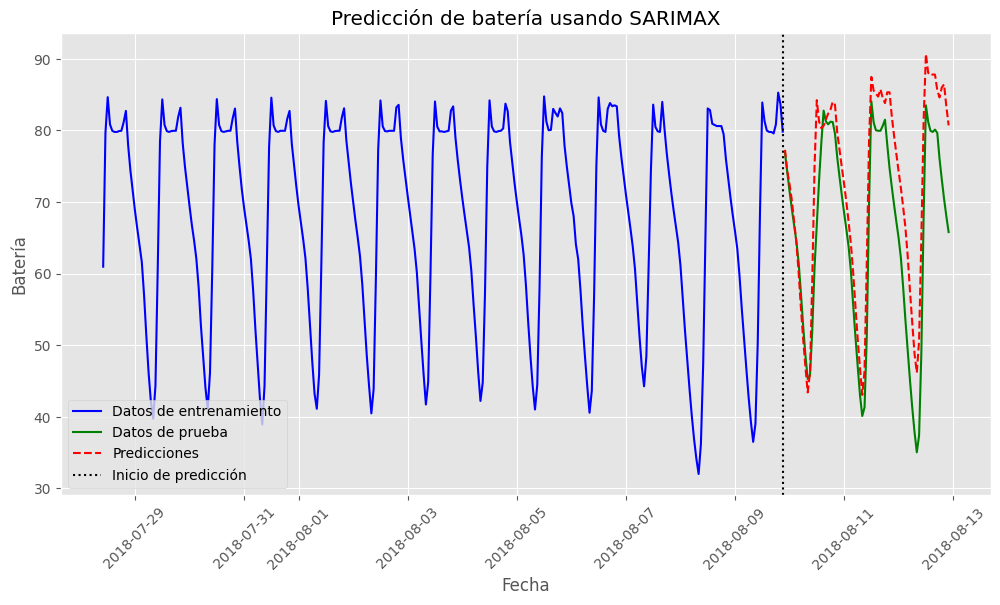

In [114]:
# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-300:], train_data[-300:], label="Datos de entrenamiento", color='blue')
plt.plot(test_data.index[0:73], test_data[0:73], label="Datos de prueba", color='green')
plt.plot(test_data.index[0:73], forecast, label="Predicciones", color='red', linestyle='--')
plt.axvline(train_data.index[-1], color='black', linestyle=':', label="Inicio de predicción")
plt.title("Predicción de batería usando SARIMAX")
plt.xlabel("Fecha")
plt.ylabel("Batería")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.savefig("SARIMAX_train.png", dpi=300, bbox_inches='tight')
plt.show()

In [115]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            battery   No. Observations:                 2302
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -4426.977
Date:                            Thu, 05 Dec 2024   AIC                           8877.953
Time:                                    10:51:33   BIC                           8946.720
Sample:                                05-06-2018   HQIC                          8903.038
                                     - 08-09-2018                                         
Covariance Type:                              opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
temperature      7.6596      1.060      7.227      0.000       5.582       9.737
pressure        -5.1438      2.233     -2.304      0.021      -9.520      -0.767
air_humidity    -2.8225      0.630     -4.483      0.000      -4.057      -1.588
wind_speed       0.3312      0.164      2.021      0.043       0.010       0.652
irradiancia     -2.4286      0.571     -4.255      0.000      -3.547      -1.310
minutos_dia    -34.3152     98.290     -0.349      0.727    -226.959     158.329
hora          1.438e-06      0.001      0.002      0.999      -0.002       0.002
ar.L1           -0.1920      0.033     -5.899      0.000      -0.256      -0.128
ma.L1            0.5958      0.033     18.323      0.000       0.532       0.660
ar.S.L24         0.1826      0.012     15.213      0.000       0.159       0.206
ma.S.L24        -0.9286      0.008   -111.601      0.000      -0.945      -0.912
sigma2           2.8096      0.043     65.208      0.000       2.725       2.894
===================================================================================
Ljung-Box (L1) (Q):                   0.55   Jarque-Bera (JB):             16701.09
Prob(Q):                              0.46   Prob(JB):                         0.00
Heteroskedasticity (H):               0.38   Skew:                             0.70
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.76e+23. Standard errors may be unstable.
"""

#### Datos de TEST

In [116]:
# Dividir los datos en entrenamiento y prueba (70% entrenamiento, 30% prueba)
train_size = int(len(test_dataset) * 0.7)
train_data = test_dataset['battery'][:train_size]
test_data = test_dataset['battery'][train_size:]

In [117]:
exog_train = X_test_norm[['temperature', 'pressure', 'air_humidity', 'wind_speed', 'irradiancia', "minutos_dia", "hora"]][:train_size]
exog_test = X_test_norm[['temperature', 'pressure', 'air_humidity', 'wind_speed', 'irradiancia', "minutos_dia", "hora"]][train_size:]

In [118]:
# Realizar predicciones sobre los datos de prueba
forecast = model_fit.predict(start=len(train_data), end=len(train_data) + 72, exog=exog_test[0:73])

In [119]:
# Evaluar las predicciones: Calcular MAE y RMSE
mae = mean_absolute_error(test_data[0:73], forecast)
rmse = np.sqrt(mean_squared_error(test_data[0:73], forecast))

# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse}")

MAE (Error Absoluto Medio): 11.633733545541057
RMSE (Raíz del Error Cuadrático Medio): 15.096561844702208


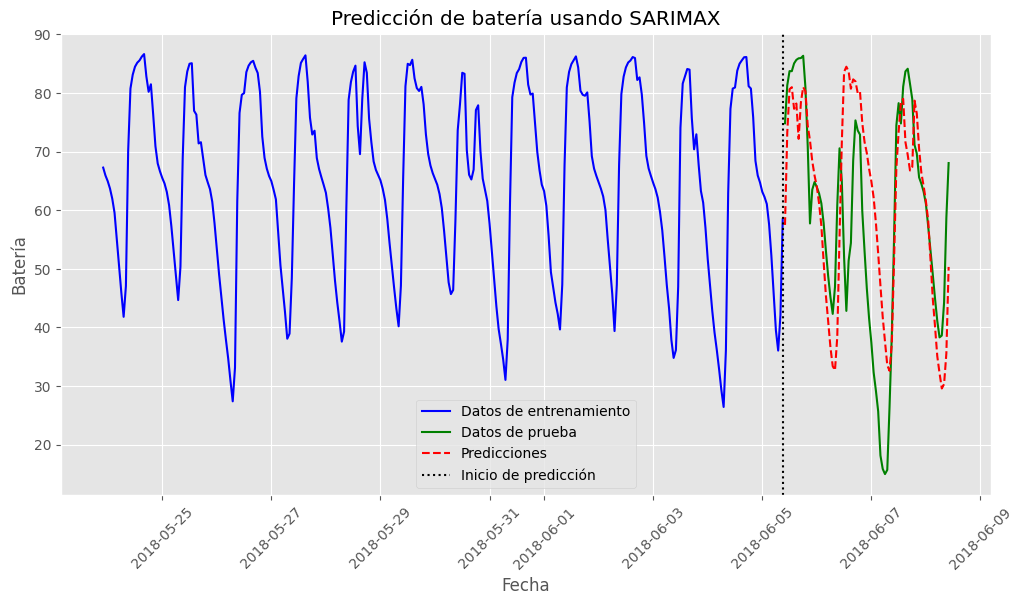

In [120]:
# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-300:], train_data[-300:], label="Datos de entrenamiento", color='blue')
plt.plot(test_data.index[0:73], test_data[0:73], label="Datos de prueba", color='green')
plt.plot(test_data.index[0:73], forecast, label="Predicciones", color='red', linestyle='--')
plt.axvline(train_data.index[-1], color='black', linestyle=':', label="Inicio de predicción")
plt.title("Predicción de batería usando SARIMAX")
plt.xlabel("Fecha")
plt.ylabel("Batería")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.savefig("SARIMAX_test.png", dpi=300, bbox_inches='tight')
plt.show()

### A los datos normalizados le aplicamos PCA n = 3 componentes

In [73]:
X_train_norm.head()

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-05-06 00:00:00,0.200275,0.574522,0.631946,0.000000,0.0,0.658683,0.000000
2018-05-06 01:00:00,0.135587,0.571512,0.696105,0.062435,0.0,0.658683,0.043478
2018-05-06 02:00:00,0.098870,0.554326,0.729686,0.000000,0.0,0.658683,0.086957
2018-05-06 03:00:00,0.094053,0.538596,0.767715,0.000000,0.0,0.658683,0.130435
2018-05-06 04:00:00,0.131594,0.527090,0.770036,0.062435,0.0,0.658683,0.173913


In [93]:
df_to_image(X_train_norm.head(), "normalizados")

qt5ct: using qt5ct plugin
qt5ct: D-Bus system tray: yes
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               


In [74]:
 # Aplicar PCA
pca = PCA(n_components=3)
data_pca = pca.fit_transform(X_train_norm)
explained_variance = pca.explained_variance_ratio_
print("Varianza explicada por cada componente principal:", explained_variance)

Varianza explicada por cada componente principal: [0.4720136  0.18670963 0.1678855 ]


In [75]:
df_pca = pd.DataFrame(data=data_pca, index=X_train_norm.index, columns=["PC1","PC2","PC3"])

In [76]:
df_pca.head()

,PC1,PC2,PC3
fecha,,,
2018-05-06 00:00:00,0.599346,-0.213078,0.088184
2018-05-06 01:00:00,0.614169,-0.173209,0.090397
2018-05-06 02:00:00,0.664017,-0.148296,0.096619
2018-05-06 03:00:00,0.672620,-0.116527,0.095019
2018-05-06 04:00:00,0.613819,-0.077690,0.087096


In [94]:
df_to_image(df_pca.head(), "df_pca3")

qt5ct: using qt5ct plugin
qt5ct: D-Bus system tray: yes
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               


In [77]:
train_data.head()

fecha
2018-05-06 00:00:00    72.690000
2018-05-06 01:00:00    69.382500
2018-05-06 02:00:00    66.723333
2018-05-06 03:00:00    63.733333
2018-05-06 04:00:00    61.465000
Name: battery, dtype: float64

In [78]:
df_pca.shape, train_data.shape

((3289, 3), (2302,))

In [79]:
SARIMAX_model = SARIMAX(train_data, exog=df_pca[0:2302], order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
#SARIMAX_model = SARIMAX(train_data, exog=df_pca[0:2302], order=(1, 1, 0))
model_fit = SARIMAX_model.fit()

/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            8     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.02873D+00    |proj g|=  1.44081D-01


 This problem is unconstrained.



At iterate    5    f=  1.95146D+00    |proj g|=  2.53060D-02

At iterate   10    f=  1.94455D+00    |proj g|=  5.82910D-03

At iterate   15    f=  1.94431D+00    |proj g|=  1.92944D-03

At iterate   20    f=  1.94421D+00    |proj g|=  2.79478D-04

At iterate   25    f=  1.94415D+00    |proj g|=  4.39192D-03

At iterate   30    f=  1.94400D+00    |proj g|=  2.12468D-04

At iterate   35    f=  1.94400D+00    |proj g|=  1.54309D-04

At iterate   40    f=  1.94398D+00    |proj g|=  2.50402D-03

At iterate   45    f=  1.94391D+00    |proj g|=  1.13685D-03


/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



At iterate   50    f=  1.94378D+00    |proj g|=  7.12551D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    8     50     55      1     0     0   7.126D-04   1.944D+00
  F =   1.9437767821869580     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


In [80]:
# Realizar predicciones sobre los datos de prueba
forecast = model_fit.predict(start=len(train_data), end=len(train_data) + 72, exog=df_pca[0:73])

In [81]:
# Evaluar las predicciones: Calcular MAE y RMSE
mae = mean_absolute_error(test_data[0:73], forecast)
rmse = np.sqrt(mean_squared_error(test_data[0:73], forecast))

# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse}")

MAE (Error Absoluto Medio): 10.438445410090807
RMSE (Raíz del Error Cuadrático Medio): 11.964283192741172


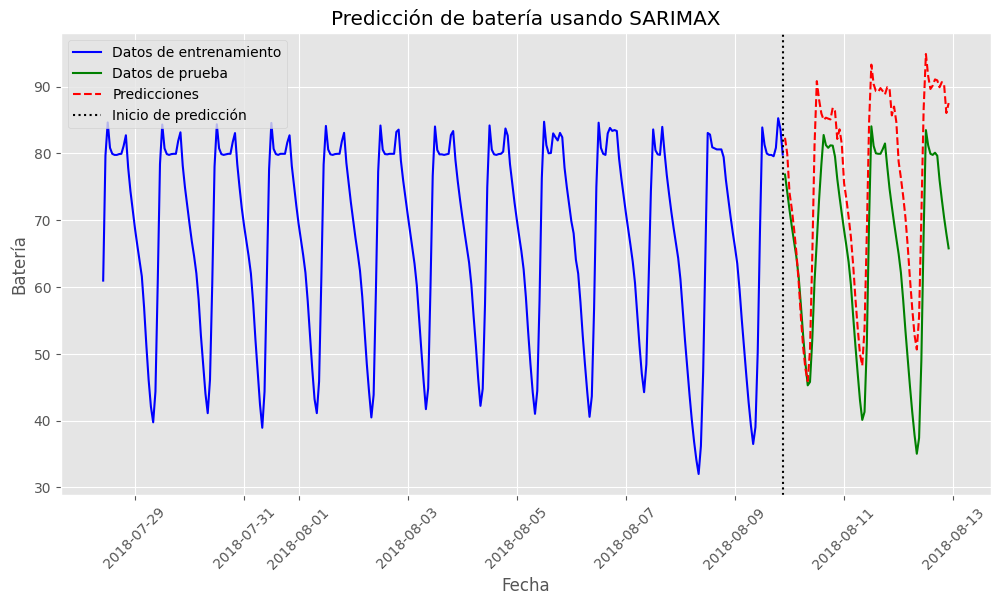

In [87]:
# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-300:], train_data[-300:], label="Datos de entrenamiento", color='blue')
plt.plot(test_data.index[0:73], test_data[0:73], label="Datos de prueba", color='green')
plt.plot(test_data.index[0:73], forecast, label="Predicciones", color='red', linestyle='--')
plt.axvline(train_data.index[-1], color='black', linestyle=':', label="Inicio de predicción")
plt.title("Predicción de batería usando SARIMAX")
plt.xlabel("Fecha")
plt.ylabel("Batería")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.savefig("SARIMAX_trainPCA3.png", dpi=300, bbox_inches='tight')
plt.show()

In [83]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            battery   No. Observations:                 2302
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -4474.574
Date:                            Thu, 05 Dec 2024   AIC                           8965.148
Time:                                    10:12:25   BIC                           9010.993
Sample:                                05-06-2018   HQIC                          8981.871
                                     - 08-09-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PC1           -2.9259      0.377     -7.762      0.000      -3.665      -2.187
PC2           -4.0293      1.428     -2.822      0.005      -6.827      -1.231
PC3           21.6445      3.432      6.307      0.000      14.918      28.371
ar.L1         -0.1913      0.031     -6.266      0.000      -0.251      -0.131
ma.L1          0.5861      0.031     19.120      0.000       0.526       0.646
ar.S.L24       0.1768      0.011     15.737      0.000       0.155       0.199
ma.S.L24      -0.9359      0.008   -118.844      0.000      -0.951      -0.920
sigma2         2.9262      0.039     75.787      0.000       2.851       3.002
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):             25229.39
Prob(Q):                              0.49   Prob(JB):                         0.00
Heteroskedasticity (H):               0.35   Skew:                             0.69
Prob(H) (two-sided):                  0.00   Kurtosis:                        19.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Datos de TEST